In [1]:
import os
import numpy as np
import pandas as pd

import geopandas as gpd

import cmocean.cm as cmo

import xarray as xr
import rasterio
import rasterio.plot as rplt
from affine import Affine

from shapely.geometry import LineString, Point

from rasterio.merge import merge
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

import app
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

app.setup_logger(use_console_handler=True, use_file_handler=False)

In [9]:
base_directory = r"D:\PhD\21_Experiments\TidesDamageDriver"
extent_folder = os.path.join(
    base_directory, "03_cleaned", "L8S2-tucket_extents_vector"
)
drainages_folder = os.path.join(
    base_directory, "02_processed", "03_drainages"
)
coastline_folder = os.path.join(
    base_directory, "01_raw", "greene2022_coastlines"
)
iceshelf_folder = os.path.join(
    base_directory, "01_raw", "greene2022_iceshelves"
)
add_path = os.path.join(
    base_directory, "01_raw", "high_res_coastline", "add_coastline_high_res_line_v7_6.shp"
)
velocity_path = os.path.join(
    base_directory, "01_raw", "velocity"
)
grid_path = os.path.join(
    base_directory, "01_raw", "grid", "ne_110m_graticules_1.shp"
)
data_dmg_folder = os.path.join(
    base_directory, "03_cleaned", "dmg_resampled"
)
figure_folder = os.path.join(
    base_directory, "figures"
)

In [3]:
years = [2016, 2018, 2019, 2020]
xmin = 2.50e6
xmax = 2.77e6
ymax = -0.215e6
ymin = -0.591e6
vertical_line = LineString([(xmin, ymin), (xmin, ymax)])

In [4]:
grid = gpd.read_file(grid_path)  # https://www.naturalearthdata.com/about/terms-of-use/
grid.to_crs("EPSG:3031", inplace=True)
grid = grid.cx[xmin:xmax, ymin:ymax]

grid_filtered = gpd.GeoDataFrame(grid[grid["degrees"].isin([65, 66, 100, 95])].cx[xmin: xmax, ymin: ymax])
grid_filtered_S = grid_filtered.query("direction == 'S'")
grid_filtered_E = grid_filtered.query("direction == 'E'")

label_points_grid = []

for idx, row in grid_filtered.iterrows():
    line = row.geometry
    intersection = line.intersection(vertical_line)

    if not intersection.is_empty:
        if intersection.geom_type == "Point":
            x_int, y_int = intersection.x, intersection.y
            if ymin <= y_int <= ymax:
                label_points_grid.append({
                    "label": row["display"],
                    "x": x_int,
                    "y": y_int
                })
        elif intersection.geom_type in ["MultiPoint", "GeometryCollection"]:
            for geom in intersection.geoms:
                if geom.geom_type == "Point":
                    x_int, y_int = geom.x, geom.y
                    if ymin <= y_int <= ymax:
                        label_points_grid.append({
                            "label": row["display"],
                            "x": x_int,
                            "y": y_int
                        })
grid.head()

,degrees,direction,display,scalerank,dd,geometry
154,65,S,65 S,6,-65,"LINESTRING (-2.112e-9 -2758494.765, 161.696 -2..."
155,66,S,66 S,6,-66,"LINESTRING (2.365 -2644909.451, 155.038 -26449..."
156,67,S,67 S,6,-67,"LINESTRING (2.264 -2531747.008, 148.404 -25317..."
256,103,E,103 E,6,103,"LINESTRING (7.141 -1.648, 52938.639 -12219.281..."
257,102,E,102 E,6,102,"LINESTRING (7.169 -1.523, 53143.83 -11293.522,..."


In [5]:
all_coastline_files = os.listdir(coastline_folder)
coastlines = [
    gpd.read_file(os.path.join(coastline_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_coastline_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
# buffer = 6e3
# coastlines_buffer = [c.buffer(buffer) for c in coastlines]

In [6]:
all_iceshelves_files = os.listdir(iceshelf_folder)
iceshelves = [
    gpd.read_file(os.path.join(iceshelf_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_iceshelves_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
ice_buffer = 150
for ice in iceshelves:
    ice.geometry = ice.buffer(ice_buffer)
    ice = ice.dissolve()
    ice.geometry = ice.buffer(-ice_buffer)
cmap = mpl.colormaps["cmo.ice"]
ice_colors = cmap(np.linspace(0.2, 0.8, 3))

buffer = 1e3
iceshelves_buffer = [i.buffer(buffer) for i in iceshelves]

In [7]:
add = gpd.read_file(
    add_path
)
add.columns
add["surface"].unique()

shelf_lines = add[add["surface"].isin(["ice shelf and front"])]
grounding_lines = add[
    add["surface"].isin(
        [
            "ice coastline",
            "grounding line",
            "ice rumples",
            "rock against ice shelf",
            "rock coastline",
        ]
    )
]

shelf = shelf_lines.cx[xmin:xmax, ymin:ymax]
grounding_line = grounding_lines.cx[xmin:xmax, ymin:ymax]

In [10]:
emaxs = []
emaxs_transforms = []
emaxs_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_emax.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        #masked = masked
        #masked = (masked / np.nanmax(masked)).copy()
    emaxs.append(masked)
    emaxs_transforms.append(masked_transform)
    emaxs_meta.append(meta)

In [11]:
vys = [f for f in os.listdir(velocity_path) if f.endswith("vy.tif")]
vxs = [f for f in os.listdir(velocity_path) if f.endswith("vx.tif")]

vy, vy_transform = merge([rasterio.open(os.path.join(velocity_path, fp)) for fp in vys])
vx, vx_transform = merge([rasterio.open(os.path.join(velocity_path, fp)) for fp in vxs])

vy *= 1e-3
vx *= 1e-3

speed = np.sqrt(vx**2 + vy**2)                # magnitude of velocity vector
angle = np.degrees(np.arctan2(vy, vx))        # flow direction in degrees
angle_shifted = ((angle + 90 + 180) % 360) - 180

print(f"Found {len(vys)} vy files and {len(vxs)} vx files.")
print(f"Velocity raster shape: {speed.shape}, transform: {vx_transform}")
print(f"vx min {np.nanmin(vx)} m/a and max {np.nanmax(vx)} m/a")
print(f"max speed {np.nanmax(speed)} m/a and mean speed {np.nanmean(speed[speed>0])} m/a and min speed {np.nanmin(speed[speed>0])} m/a")
print(f"max angle {np.nanmax(angle)}° and min angle {np.nanmin(angle)}°")
print(f"max shifted angle {np.nanmax(angle_shifted)}° and min shifted angle {np.nanmin(angle_shifted)}°")

Found 5 vy files and 5 vx files.
Velocity raster shape: (1, 1769, 1179), transform: | 300.00, 0.00, 2540700.00|
| 0.00,-300.00,-110700.00|
| 0.00, 0.00, 1.00|
vx min -0.37175044417381287 m/a and max 1.860901951789856 m/a
max speed 1.9092295169830322 m/a and mean speed 0.26942625641822815 m/a and min speed 9.55693976720795e-05 m/a
max angle 179.99977111816406° and min angle -179.99781799316406°
max shifted angle 179.99789428710938° and min shifted angle -179.9935302734375°


In [17]:
np.nanmin(emaxs[0])

np.float32(-0.032614015)

C:\Users\jsommer1\AppData\Local\Temp\ipykernel_24500\645298620.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


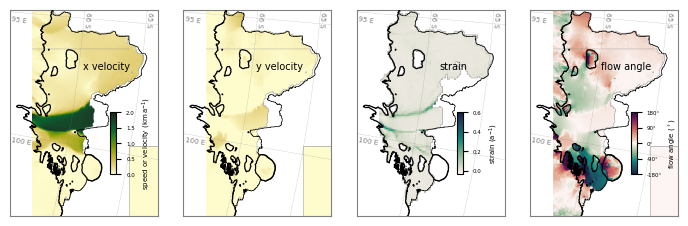

In [23]:
total_width = 18 / 2.54
gird_label_font_size = 5
fig, axes = plt.subplots(1, 4, figsize=(total_width, 6 / 2.54), sharex=True, sharey=True)
i_year = 2

label = ["x velocity", "y velocity", "strain", "flow angle"]

ax = axes.ravel()[0]
rplt.show(vx, transform=vx_transform, ax=ax, cmap=cmo.speed, vmin=0, vmax=2, zorder=1)

im = ax.imshow(speed[0, :, :], cmap=cmo.speed, vmin=0, vmax=2)
# Create an inset axes for the colorbar
cax = inset_axes(ax,
                width="4%",    # width of colorbar relative to plot
                height="30%",  # height of colorbar relative to plot
                loc='lower right',  # position: 'upper right', 'lower left', etc.
                borderpad=3.0)  # padding from the edge

# Create colorbar
cbar = fig.colorbar(im, cax=cax, cmap=cmo.speed, orientation='vertical')
cbar.set_label(r'speed or velocity ($\mathrm{km}\,\mathrm{a}^{-1}$)', fontsize=5)
cbar.ax.tick_params(labelsize=4)

ax = axes.ravel()[1]
rplt.show(vy, transform=vx_transform, ax=ax, cmap=cmo.speed, vmin=0, vmax=2, zorder=1)

ax = axes.ravel()[2]
rplt.show(emaxs[1], transform=emaxs_transforms[1], ax=ax, cmap=cmo.tempo, vmin=-0.035, vmax=0.6, zorder=1)

im = ax.imshow(emaxs[1][0, :, :], cmap=cmo.tempo, vmin=-0.035, vmax=0.6)
# Create an inset axes for the colorbar
cax = inset_axes(ax,
                width="4%",    # width of colorbar relative to plot
                height="30%",  # height of colorbar relative to plot
                loc='lower right',  # position: 'upper right', 'lower left', etc.
                borderpad=3.0)  # padding from the edge

# Create colorbar
cbar = fig.colorbar(im, cax=cax, cmap=cmo.tempo, orientation='vertical')
cbar.set_label(r'strain ($\mathrm{a}^{-1}$)', fontsize=5)
cbar.ax.tick_params(labelsize=4)


ax = axes.ravel()[3]
rplt.show(angle, transform=vx_transform, ax=ax, cmap=cmo.curl, vmin=-180, vmax=180, zorder=1)

im = ax.imshow(angle[0, :, :], cmap=cmo.curl, vmin=-180, vmax=180)
# Create an inset axes for the colorbar
cax = inset_axes(ax,
                width="4%",    # width of colorbar relative to plot
                height="30%",  # height of colorbar relative to plot
                loc='lower right',  # position: 'upper right', 'lower left', etc.
                borderpad=3.0)  # padding from the edge

# Create colorbar
cbar = fig.colorbar(im, cax=cax, cmap=cmo.speed, orientation='vertical')
cbar.set_label(r'flow angle ($^\circ$)', fontsize=5)
cbar.ax.tick_params(labelsize=4)
cbar.set_ticks(np.arange(-180, 181, 90))
cbar.set_ticklabels(['-180°', '-90°', '0°', '90°', '180°'])

# vx_ = vx[0, :, :]  # shape now (36, 1179)
# vy_ = vy[0, :, :]  # shape now (36, 1179)

# step = 50  # reduce density
# vy_plot = vy_[::step, ::step]
# vx_plot = vx_[::step, ::step]

# rows, cols = np.meshgrid(np.arange(vx_plot.shape[0]), np.arange(vx_plot.shape[1]), indexing="ij")
# xs, ys = rasterio.transform.xy(vx_transform, rows * step, cols * step, offset="center")
# print(xs.shape, ys.shape, vx_plot.shape, vy_plot.shape)
# xs = np.array(xs)
# ys = np.array(ys)

# # plot arrows on top of the speed map
# ax = axes.ravel()[1]
# ax.quiver(xs, ys, vx_plot, vy_plot, color='black', scale=1e4, width=0.001, zorder=20)

# ax = axes.ravel()[1]
# ax.streamplot(xs[0, :], ys[:, 0], vx_plot, vy_plot, color='k', density=1.2, linewidth=0.5, arrowsize=0.5, zorder=20)


for i_ax, ax in enumerate(axes.ravel()):
    ax = axes.ravel()[i_ax]
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    grid_filtered.plot(ax=ax, color="gray", linewidth=0.2, alpha=0.8, ls="--", zorder = 15)
    coastlines[i_year].plot(ax=ax, facecolor="none", edgecolor="black", lw=0.5, zorder = 3)
    grounding_line.plot(ax=ax, facecolor="none", edgecolor="black", lw=0.9, zorder = 3)

    # S labels (assume all same Y)
    ys = np.full(len(grid_filtered_S), ymax - 3e3)
    xs = grid_filtered_S.bounds.maxx - 5e3
    labels = grid_filtered_S['degrees'].astype(str) + ' S'

    for x, y, s in zip(xs, ys, labels):
        ax.text(x, y, s, rotation=-96, ha="center", va="top",
                fontsize=gird_label_font_size, color="gray", zorder=16)

    # E labels (assume all same Y)
    label_lookup = {l['label']: l['y'] for l in label_points_grid}
    xs = np.full(len(grid_filtered_E), xmin + 2e3)
    ys = grid_filtered_E['display'].map(label_lookup) - 1.5e4
    labels = grid_filtered_E['degrees'].astype(str) + ' E'

    for x, y, s in zip(xs, ys, labels):
        ax.text(x, y, s, rotation=-9, ha="left", va="center",
                fontsize=gird_label_font_size, color="gray", zorder=16)

    ax.tick_params(
            axis="both",  # changes apply to the x-axis
            which="both",  # both major and minor ticks are affected
            bottom=False,  # ticks along the bottom edge are off
            top=False,  # ticks along the top edge are off
            left=False,
            right=False,
            labelbottom=False,
            labelleft=False,
        )
    #ax.text(x = 0.7, y = 0.1, s=str(year), transform=ax.transAxes)
    
    ax.spines["bottom"].set_color("gray")
    ax.spines["top"].set_color("gray")
    ax.spines["left"].set_color("gray")
    ax.spines["right"].set_color("gray")

    ax.text(0.65, 0.7, label[i_ax], transform=ax.transAxes, ha="center", va="bottom", fontsize=7)

    

plt.tight_layout()
plt.savefig(
    os.path.join(figure_folder, f"figure_S5.png"),
    dpi=300,
)
plt.savefig(
    os.path.join(figure_folder, f"figure_S5.pdf"),
    dpi=300,
)
plt.show()